# Problem Set 1 - Basic Julia (Solutions)

# Loops and Conditionals

## Problem 1: Present Discounted Value

The present discounted value of a stream of payments
$y_0, y_1, \ldots, y_T$ is:

$$PV = \sum_{t=0}^{T} \beta^t y_t$$

**(a)** Suppose $y_t = 100$ for all $t$ and $\beta = 0.95$. Compute $PV$
for $T = 30$ using a `for` loop.

In [1]:
β = 0.95
T = 30

PV = 0.0
for t in 0:T
    PV += β^t * 100
end
println("Present discounted value: $PV")

Present discounted value: 1592.1863485084177

**(b)** Now suppose income grows at rate $g = 0.02$ per year, so
$y_t = 100 \cdot (1+g)^t$. Compute the present discounted value for
$T = 30$ and $\beta = 0.95$.

In [1]:
g = 0.02

PV_growth = 0.0
for t in 0:T
    yₜ = 100 * (1 + g)^t
    PV_growth += β^t * yₜ
end
println("PV with income growth: $PV_growth")

PV with income growth: 2010.529126741194

## Problem 2: Tax Brackets

The US federal income tax has a progressive bracket structure. Consider
a simplified version with three brackets:

| Taxable Income       | Marginal Rate |
|----------------------|---------------|
| \$0 – \$50,000       | 10%           |
| \$50,001 – \$100,000 | 20%           |
| Over \$100,000       | 30%           |

**(a)** Write a function `tax(income)` that computes the total tax owed
under this bracket structure. Remember, the marginal rate applies only
to income *within* each bracket. For example, someone earning \$75,000
pays 10% on the first \$50,000 and 20% on the remaining \$25,000.

In [1]:
function tax(income)
    if income <= 50_000
        return 0.10 * income
    elseif income <= 100_000
        return 0.10 * 50_000 + 0.20 * (income - 50_000)
    else
        return 0.10 * 50_000 + 0.20 * 50_000 + 0.30 * (income - 100_000)
    end
end

tax (generic function with 1 method)

**(b)** Use your function to compute the tax owed on incomes of
\$30,000, \$75,000, and \$150,000.

In [1]:
for inc in [30_000, 75_000, 150_000]
    t = tax(inc)
    println("Income: \$$inc → Tax owed: \$$t")
end

Income: $30000 → Tax owed: $3000.0
Income: $75000 → Tax owed: $10000.0
Income: $150000 → Tax owed: $30000.0

**(c)** Compute the **average tax rate** (tax owed divided by income)
for each of the three incomes above. Verify that the average rate is
increasing in income (this is what makes the tax *progressive*).

In [1]:
for inc in [30_000, 75_000, 150_000]
    avg_rate = tax(inc) / inc
    println("Income: \$$inc → Average tax rate: $(round(avg_rate * 100, digits=2))%")
end

Income: $30000 → Average tax rate: 10.0%
Income: $75000 → Average tax rate: 13.33%
Income: $150000 → Average tax rate: 20.0%

The average tax rate rises with income: 10% at \$30,000, 13.33% at
\$75,000, and 20% at \$150,000. The tax system is progressive:
higher-income earners pay a larger share of their income in taxes, even
though the marginal rate only applies to income within each bracket.

# Functions

## Problem 3: Compound Interest

**(a)** Write a function `compound(P, r, n, t)` that computes the future
value of an investment with:

-   `P`: principal (initial investment)
-   `r`: annual interest rate (as a decimal)
-   `n`: number of times interest is compounded per year
-   `t`: number of years

The formula is: $FV = P\left(1 + \frac{r}{n}\right)^{nt}$

Give `n` a default value of 12 (monthly compounding).

In [1]:
function compound(P, r, n=12, t=1)
    return P * (1 + r/n)^(n*t)
end

compound (generic function with 3 methods)

**(b)** If you invest \$10,000 at 5% annual interest, what is the future
value after 10 years with monthly compounding? What about daily
compounding ($n = 365$)?

In [1]:
fv_monthly = compound(10_000, 0.05, 12, 10)
fv_daily = compound(10_000, 0.05, 365, 10)
println("Monthly compounding: \$$(round(fv_monthly, digits=2))")
println("Daily compounding:   \$$(round(fv_daily, digits=2))")

Monthly compounding: $16470.09
Daily compounding:   $16486.65

## Problem 4: Simulating a Random Walk with Drift

A **random walk with drift** is a generalization of the AR(1) process
from lecture:

$$x_t = \mu + x_{t-1} + \sigma \epsilon_t, \quad \epsilon_t \sim N(0,1)$$

where $\mu$ is the drift (trend) and $\sigma$ is the volatility.

**(a)** Write a function `random_walk(x0, T, μ, σ)` that simulates `T`
periods of this process starting from `x0`. Give `μ` a default value of
0.0 and `σ` a default value of 1.0. Include a docstring.

In [1]:
using Random

"""
    random_walk(x0, T, μ=0.0, σ=1.0)

Simulate `T` periods of a random walk with drift starting from `x0`.

The process is: xₜ = μ + xₜ₋₁ + σεₜ, where εₜ ~ N(0,1).
Returns a vector of length T+1 (including the initial value).
"""
function random_walk(x0, T; μ=0.0, σ=1.0)
    x = zeros(T + 1)
    x[1] = x0
    for t in 2:(T + 1)
        x[t] = μ + x[t-1] + σ * randn()
    end
    return x
end

Main.Notebook.random_walk

Note this is technially using *keyword arguments* to set the default
values for `μ` and `σ`. Keyword arguments are defined by the semicolon
`;` in the function definition. They have the advantage that they can be
set in any order by name. See part b.

**(b)** Simulate and plot two paths of length 100: one with $\mu = 0$
(pure random walk) and one with $\mu = 0.5$ (random walk with drift).
Both should start at $x_0 = 0$ with $\sigma = 1$.

*Hint:* Use `using Plots`, then `plot()` and `plot!()` to overlay the
two paths.


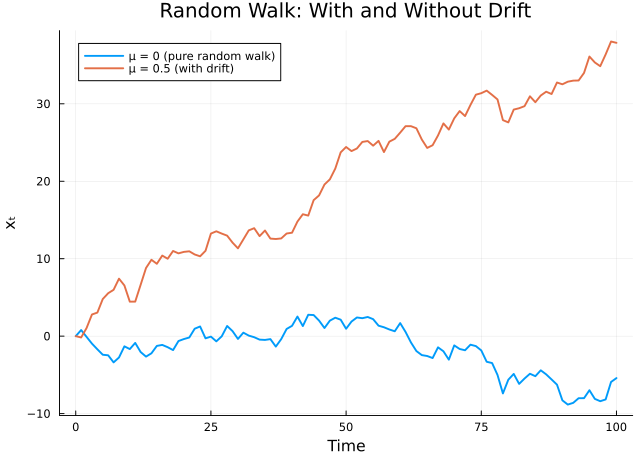

In [1]:
using Plots

Random.seed!(42)

path_no_drift = random_walk(0.0, 100; μ=0.0, σ=1.0)
path_drift = random_walk(0.0, 100; μ=0.5, σ=1.0)

plot(0:100, path_no_drift, label="μ = 0 (pure random walk)", lw=2)
plot!(0:100, path_drift, label="μ = 0.5 (with drift)", lw=2)
xlabel!("Time")
ylabel!("xₜ")
title!("Random Walk: With and Without Drift")

# Root Solving with NonlinearSolve

## Problem 5: Demand Shocks and Elasticity

In lecture we found the equilibrium price for a market with
constant-elasticity demand and supply:

$$D(p) = A\, p^{-\epsilon_d}, \quad S(p) = B\, p^{\,\epsilon_s}$$

Fix the supply elasticity at $\epsilon_s = 1$ and set $A = B = 100$ so
that the initial equilibrium price is $p^* = 1$ regardless of the demand
elasticity.

**(a)** Write a function `solve_equilibrium(A, B, εd, εs)` that uses
`NonlinearSolve` to find the equilibrium price and returns $(p^*, Q^*)$
where $Q^* = S(p^*)$. Verify that when $A = B = 100$ and
$\epsilon_s = 1$, the equilibrium price is $p^* = 1$ for
$\epsilon_d \in \{0.5, 1.0, 2.0\}$.

In [1]:
using NonlinearSolve

function solve_equilibrium(A, B, εd, εs)
    excess_demand(p, params) = [A * p[1]^(-εd) - B * p[1]^εs]
    prob = NonlinearProblem(excess_demand, [2.0])
    sol = solve(prob, NewtonRaphson())
    p_star = sol.u[1]
    Q_star = B * p_star^εs
    return p_star, Q_star
end

for εd in [0.5, 1.0, 2.0]
    p_star, Q_star = solve_equilibrium(100, 100, εd, 1.0)
    println("εd = $εd: p* = $(round(p_star, digits=4)), Q* = $(round(Q_star, digits=4))")
end

εd = 0.5: p* = 1.0, Q* = 100.0
εd = 1.0: p* = 1.0, Q* = 100.0
εd = 2.0: p* = 1.0, Q* = 100.0

**(b)** Suppose demand shifts up to $A = 120$ (a 20% demand shock).
Using your function, find the new equilibrium price for
$\epsilon_d \in \{0.5, 1.0, 2.0\}$ (keeping $B = 100$,
$\epsilon_s = 1$). Report the percentage change in price for each case.

In [1]:
for εd in [0.5, 1.0, 2.0]
    p_star, Q_star = solve_equilibrium(120, 100, εd, 1.0)
    pct_change = (p_star - 1.0) / 1.0 * 100
    println("εd = $εd: p* = $(round(p_star, digits=4)), ΔP = $(round(pct_change, digits=2))%, Q* = $(round(Q_star, digits=4))")
end

εd = 0.5: p* = 1.1292, ΔP = 12.92%, Q* = 112.9243
εd = 1.0: p* = 1.0954, ΔP = 9.54%, Q* = 109.5445
εd = 2.0: p* = 1.0627, ΔP = 6.27%, Q* = 106.2659

**(c)** Plot the equilibrium price as a function of $A$ for
$A \in [100, 200]$, with a separate curve for each
$\epsilon_d \in \{0.5, 1.0, 2.0\}$. How does the demand elasticity
affect the size of the price response to a demand shock? Give a brief
economic intuition.


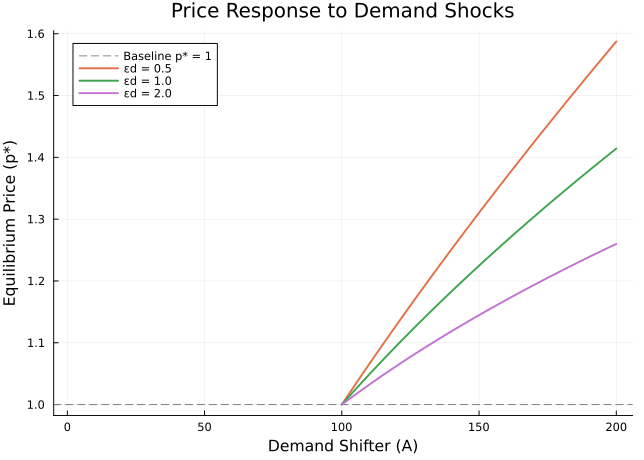

In [1]:
using Plots

A_grid = 100:2:200

plt = plot(xlabel="Demand Shifter (A)", ylabel="Equilibrium Price (p*)",
           title="Price Response to Demand Shocks")
hline!([1.0], linestyle=:dash, color=:gray, label="Baseline p* = 1")

for εd in [0.5, 1.0, 2.0]
    prices = [solve_equilibrium(A, 100, εd, 1.0)[1] for A in A_grid]
    plot!(plt, A_grid, prices, lw=2, label="εd = $εd")
end

plt

When demand is **inelastic** ($\epsilon_d = 0.5$), a demand shock causes
a large price increase. Consumers are not very responsive to price, so
the price must rise substantially before quantity demanded falls enough
to match the higher quantity supplied at the new price. Conversely, when
demand is **elastic** ($\epsilon_d = 2.0$), even a small price increase
causes consumers to cut back sharply, so the market clears with only a
modest rise in price. Formally, the equilibrium price is
$p^* = (A/B)^{1/(\epsilon_d + \epsilon_s)}$, so higher $\epsilon_d$
dampens the price response to any change in $A/B$.

# Optimization with Optim

## Problem 6: CES Utility — Expenditure across $\rho$

In lecture we maximized CES utility
$U(x_1, x_2) = (\alpha x_1^\rho + (1-\alpha) x_2^\rho)^{1/\rho}$ subject
to the budget constraint $p_1 x_1 + p_2 x_2 = I$.

Fix $p_1 = p_2 = 1$, $I = 100$, and $\alpha = 0.5$. When prices are
equal, the optimal bundle is $(x_1^*, x_2^*) = (50, 50)$ for **any**
$\rho$ (same bundle across different elasticities of substitution).

**(a)** Write a function that takes $(p_1, p_2, I, \rho)$ as arguments
and returns the optimal bundle $(x_1^*, x_2^*)$. Use `Optim` to maximize
CES utility, substituting $x_2 = (I - p_1 x_1)/p_2$ from the budget
constraint. Verify that when $p_1 = p_2 = 1$ and $I = 100$, you get
$(50, 50)$ for $\rho \in \{-1, 0.5\}$.

In [1]:
using Optim

function ces_optimal(p1, p2, I, ρ; α=0.5)
    function neg_utility(x1)
        x2 = (I - p1 * x1) / p2
        if x1 <= 0 || x2 <= 0
            return 1e10
        end
        U = (α * x1^ρ + (1 - α) * x2^ρ)^(1/ρ)
        return -U
    end

    result = optimize(neg_utility, 0.01, I/p1 - 0.01, Optim.Brent())
    x1_star = Optim.minimizer(result)
    x2_star = (I - p1 * x1_star) / p2
    return x1_star, x2_star
end

for ρ in [-1.0, 0.5]
    x1, x2 = ces_optimal(1.0, 1.0, 100.0, ρ)
    println("ρ = $ρ: x1* = $(round(x1, digits=2)), x2* = $(round(x2, digits=2))")
end

ρ = -1.0: x1* = 50.0, x2* = 50.0
ρ = 0.5: x1* = 50.0, x2* = 50.0

**(b)** For $\rho \in \{-1, -0.01, 0.5\}$ (complements, nearly
Cobb-Douglas, substitutes) and $p_2 \in \{0.5, 1.0, 1.5, 2.0\}$ (keeping
$p_1 = 1$, $I = 100$), compute the optimal bundle and **expenditure on
each good** for each $(\rho, p_2)$ pair.

In [1]:
ρ_vals = [-1.0, -0.01, 0.5]
p2_vals = [0.5, 1.0, 1.5, 2.0]

println("ρ\t\tp2\tx1*\tx2*\tExp1\tExp2")
println("-"^70)
for ρ in ρ_vals
    for p2 in p2_vals
        x1, x2 = ces_optimal(1.0, p2, 100.0, ρ)
        exp1 = 1.0 * x1
        exp2 = p2 * x2
        println("$(ρ)\t\t$(p2)\t$(round(x1, digits=2))\t$(round(x2, digits=2))\t$(round(exp1, digits=2))\t$(round(exp2, digits=2))")
    end
    println()
end

ρ       p2  x1* x2* Exp1    Exp2
----------------------------------------------------------------------
-1.0        0.5 58.58   82.84   58.58   41.42
-1.0        1.0 50.0    50.0    50.0    50.0
-1.0        1.5 44.95   36.7    44.95   55.05
-1.0        2.0 41.42   29.29   41.42   58.58

-0.01       0.5 50.17   99.66   50.17   49.83
-0.01       1.0 50.0    50.0    50.0    50.0
-0.01       1.5 49.9    33.4    49.9    50.1
-0.01       2.0 49.83   25.09   49.83   50.17

0.5     0.5 33.33   133.33  33.33   66.67
0.5     1.0 50.0    50.0    50.0    50.0
0.5     1.5 60.0    26.67   60.0    40.0
0.5     2.0 66.67   16.67   66.67   33.33


**(c)** Plot **expenditure on good 1** and **expenditure on good 2** as
a function of $p_2$, with a separate curve for each value of $\rho$. Use
two plots: one for expenditure on good 1 vs. $p_2$, one for expenditure
on good 2 vs. $p_2$. Each plot should have three lines corresponding to
$\rho = -1$, $-0.01$, and $0.5$.


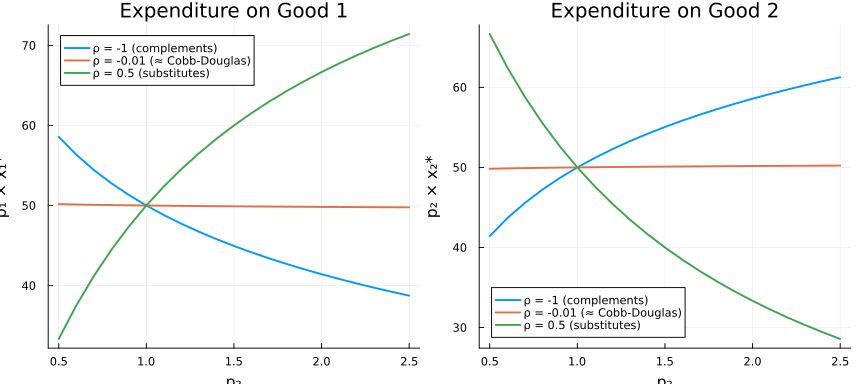

In [1]:
using Plots

p2_grid = 0.5:0.1:2.5
ρ_labels = Dict(-1.0 => "ρ = -1 (complements)",
                -0.01 => "ρ = -0.01 (≈ Cobb-Douglas)",
                 0.5 => "ρ = 0.5 (substitutes)")

plt1 = plot(title="Expenditure on Good 1", xlabel="p₂", ylabel="p₁ × x₁*")
plt2 = plot(title="Expenditure on Good 2", xlabel="p₂", ylabel="p₂ × x₂*")

for ρ in ρ_vals
    exp1_vec = Float64[]
    exp2_vec = Float64[]
    for p2 in p2_grid
        x1, x2 = ces_optimal(1.0, p2, 100.0, ρ)
        push!(exp1_vec, 1.0 * x1)
        push!(exp2_vec, p2 * x2)
    end
    plot!(plt1, p2_grid, exp1_vec, label=ρ_labels[ρ], lw=2)
    plot!(plt2, p2_grid, exp2_vec, label=ρ_labels[ρ], lw=2)
end

plot(plt1, plt2, layout=(1, 2), size=(900, 400))

**(d)** How does the elasticity of substitution $\sigma = 1/(1-\rho)$
affect how expenditure responds to a change in $p_2$? Give a brief
economic interpretation.

The elasticity of substitution $\sigma = 1/(1-\rho)$ governs how easily
consumers switch between the two goods:

-   **Substitutes ($\rho = 0.5$, $\sigma = 2$):** When $p_2$ rises,
    consumers aggressively shift expenditure toward the now-cheaper
    good 1. Expenditure on good 1 rises sharply and expenditure on good
    2 falls, because consumers can easily substitute between goods.

-   **Near Cobb-Douglas ($\rho \approx 0$, $\sigma \approx 1$):**
    Expenditure shares are approximately constant. When $p_2$ rises, the
    consumer buys less of good 2 but spends roughly the same dollar
    amount on each good. This is the classic unit-elasticity result
    where income and substitution effects on expenditure shares exactly
    offset.

-   **Complements ($\rho = -1$, $\sigma = 0.5$):** When $p_2$ rises, the
    consumer cannot easily substitute away from good 2 (the goods must
    be consumed together). Expenditure on good 2 actually increases
    (buying somewhat less at a much higher price), while expenditure on
    good 1 falls as the consumer is forced to devote more of the budget
    to the expensive complement.

## Problem 7: Labor-Leisure Choice with Frisch Elasticity

A consumer has log utility over consumption and labor disutility with
constant **Frisch elasticity** $\varphi$. The utility function is:

$$u(c, L) = \log(c) - \frac{\eta}{1 + 1/\varphi}\, L^{1 + 1/\varphi}$$

where $c$ is consumption, $L$ is labor supply, $\eta > 0$ is a
disutility scale parameter, and $\varphi > 0$ is the Frisch elasticity
of labor supply. The budget constraint is $c = wL + A$, where $w$ is the
wage and $A \geq 0$ is unearned income.

We **normalize** so that $L^* = 1$ when $w = 1$ and $A = 0$. This pins
down $\eta = 1$.

**(a)** Write a function `neg_utility(L; w, A, η, φ)` that returns minus
the utility (for use with `Optim`, which minimizes). Use it with `Optim`
to find the optimal labor supply $L^*$ for $w = 1$, $A = 0$, $\eta = 1$,
and $\varphi = 0.5$. Verify that $L^* = 1$ (confirming the
normalization). Report $L^*$, consumption $c^*$, and utility at the
optimum.

In [1]:
using Optim

function neg_utility(L; w=1.0, A=0.0, η=1.0, φ=0.5)
    if L <= 0
        return 1e10
    end
    c = w * L + A
    if c <= 0
        return 1e10
    end
    u = log(c) - (η / (1 + 1/φ)) * L^(1 + 1/φ)
    return -u
end

result = optimize(L -> neg_utility(L; w=1.0, A=0.0, η=1.0, φ=0.5), 0.01, 5.0, Optim.Brent())
L_star = Optim.minimizer(result)
c_star = 1.0 * L_star + 0.0
u_star = -Optim.minimum(result)

println("L* = $(round(L_star, digits=4))")
println("c* = $(round(c_star, digits=4))")
println("Utility = $(round(u_star, digits=4))")

L* = 1.0
c* = 1.0
Utility = -0.3333

**(b)** Now fix $w = 1$ and vary $A \in \{0, 0.5, 1.0, 2.0\}$. How does
labor supply respond to unearned income? Give an economic
interpretation. Plot $L^*$ as a function of $A$.


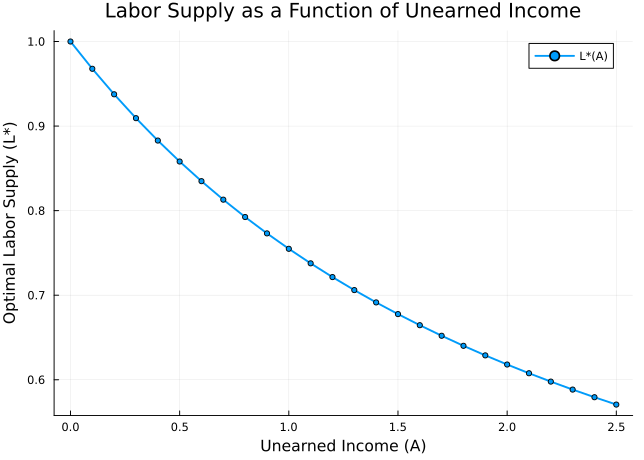

In [1]:
using Plots

A_vals = 0.0:0.1:2.5
L_vals_A = Float64[]

for A in A_vals
    res = optimize(L -> neg_utility(L; w=1.0, A=A, η=1.0, φ=0.5), 0.01, 5.0, Optim.Brent())
    push!(L_vals_A, Optim.minimizer(res))
end

plot(A_vals, L_vals_A, lw=2, label="L*(A)", marker=:circle, markersize=3)
xlabel!("Unearned Income (A)")
ylabel!("Optimal Labor Supply (L*)")
title!("Labor Supply as a Function of Unearned Income")

Labor supply is decreasing in unearned income. This is a pure income
effect: when the worker has more non-labor income, they are wealthier
and can afford to consume more leisure (work less) without sacrificing
consumption as much. Leisure is a normal good, so higher wealth reduces
labor supply. Economically, this captures the intuition that a worker
who receives a dividend check or inheritance will choose to work fewer
hours.

**(c)** Plot $L^*$ as a function of $A$ for both $\varphi = 0.5$ and
$\varphi = 2.0$ on the same axes (with $w = 1$). How does the Frisch
elasticity affect the responsiveness of labor supply to unearned income?


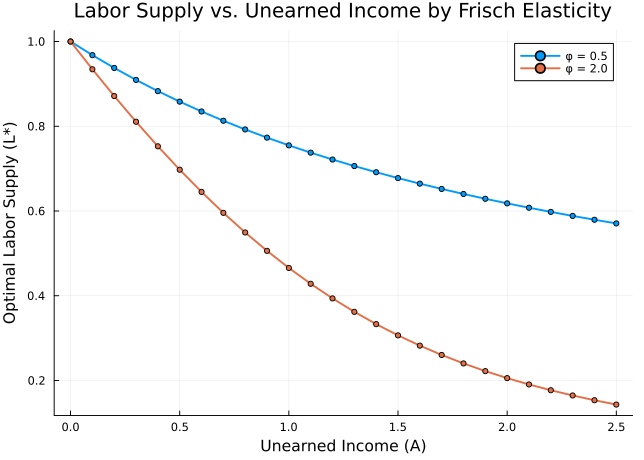

In [1]:
using Plots

A_grid = 0.0:0.1:2.5

plt = plot(xlabel="Unearned Income (A)", ylabel="Optimal Labor Supply (L*)",
           title="Labor Supply vs. Unearned Income by Frisch Elasticity")

for φ in [0.5, 2.0]
    L_vec = Float64[]
    for A in A_grid
        res = optimize(L -> neg_utility(L; w=1.0, A=A, η=1.0, φ=φ), 0.01, 5.0, Optim.Brent())
        push!(L_vec, Optim.minimizer(res))
    end
    plot!(plt, A_grid, L_vec, lw=2, label="φ = $φ", marker=:circle, markersize=3)
end

plt

A higher Frisch elasticity ($\varphi = 2.0$) means labor supply is more
responsive to changes in economic incentives. When unearned income
rises, the worker with $\varphi = 2.0$ reduces labor supply more steeply
than the worker with $\varphi = 0.5$. Intuitively, the Frisch elasticity
measures how willing the worker is to adjust hours on the margin. A
high-$\varphi$ worker finds it easy to substitute between labor and
leisure, so they respond more strongly to the wealth effect from
unearned income by cutting back hours. A low-$\varphi$ worker has more
rigid labor supply and adjusts less, even as unearned income grows.